# Microsoft Foundry Agent Service and LangGraph

This notebook demonstrates how to use Microsoft Foundry Agent Service with LangGraph through the `langchain-azure-ai` integration.

## Prerequisites

1. A Microsoft Foundry project using the new Foundry experience.
2. A deployed model (e.g., gpt-4.1)
3. Appropriate authentication credentials
4. Environment variables set:

   - `AZURE_AI_PROJECT_ENDPOINT`

5. Install `langchain-azure-ai`
   
   `pip install -U langchain-azure-ai[tools,opentelemetry]` 

In [ ]:
import os

# Set up environment variables 
# note project connnection string is no longer supported
os.environ["AZURE_AI_PROJECT_ENDPOINT"] = "https://<resource>.ai.azure.com/api/projects/<project_id>"
os.environ["MODEL_DEPLOYMENT_NAME"] = "gpt-4.1"

If finding troubles, enable diagnostic logging:

In [ ]:
# Enable debug logging
import logging

logging.getLogger("langchain_azure_ai").setLevel(logging.DEBUG)

## Getting started

Use the `AgentServiceFactory` class to create LangGraph nodes that work with Microsoft Foundry Agent Service.

In [17]:
from langchain_azure_ai.agents import AgentServiceFactory
from azure.identity import DefaultAzureCredential

factory = AgentServiceFactory()

You can create and deploy complex agents using Microsoft Foundry Agent Service and then integrate them into your LangGraph solutions. If you already have agents created in the Microsoft Foundry, just reference them by name:

In [3]:
echo_node = factory.get_agent_node(name="my-echo-agent", version="latest")

Test that your agent can run:

In [4]:
from langchain.messages import HumanMessage

response = echo_node.invoke({"messages": [HumanMessage(content="Hello, world!")]})
print(response["messages"].content)

Goodbye, universe!


### Conversations and state

Nodes attached to the Agent Service automatically track responses in conversations. Those properties are added to the state:

In [5]:
print("azure_ai_agents_conversation_id:", response["azure_ai_agents_conversation_id"])

azure_ai_agents_conversation_id: conv_5eaed15cd4ffd84500IGbJW51ktstsRsMixdFnbOL9Ef2h2RNs


### Composing complex graphs

You can Agent Service nodes in the same way you use any other node in LangGraph. To demonstrate how to do it, let's create a simple router/expert graph. The following code builds a LangGraph conditional routing graph with two nodes and a branching decision:

* `router_node` — Inspects the last message. If it contains "negate", sets `jump_to="delegate"` (forwarding the original messages) to delegate execution to Agent Service.
* `expert_node` — Bound to `echo_node` (a Foundry agent created earlier). This is the "specialist" that handles delegated requests.

In [6]:
from typing import Literal
from langchain.chat_models import init_chat_model
from langchain.messages import AIMessage
from langgraph.graph import StateGraph, MessagesState, START, END


class RouterState(MessagesState):
    jump_to: str | None


def router_node(state: RouterState):
    last_message = state["messages"][-1].content.lower()
    
    # Simple logic simulating a model decision
    if "negate" in last_message:
        return RouterState(messages=state["messages"], jump_to="delegate")
    else:
        return RouterState(messages=[AIMessage(content="I can handle this!")], jump_to=None)


def route_decision(state: RouterState) -> Literal["expert_node", END]:
    if state.get("jump_to", None) == "delegate":
        return "expert_node"
    return END

# 4. Build Graph
workflow = StateGraph(RouterState)

workflow.add_node("router_node", router_node)
workflow.add_node("expert_node", echo_node)
workflow.add_edge(START, "router_node")
workflow.add_conditional_edges("router_node", route_decision)
workflow.add_edge("expert_node", END)

app = workflow.compile()


Let's see the graph:

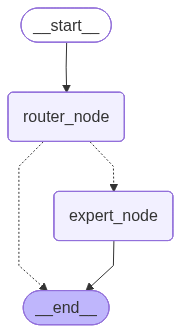

In [7]:
from IPython import display

display.Image(app.get_graph().draw_mermaid_png())

Let's see an example:

In [8]:
from langchain_azure_ai.utils.agents import pretty_print

print("------------------------------- Test 1 (Direct) --------------------------------")
pretty_print(app.invoke({"messages": [HumanMessage(content="Hello, world!")]}))

print("\n------------------------------- Test 2 (Delegated) -----------------------------")
pretty_print(app.invoke({"messages": [HumanMessage(content="Negate that I'm a genius!")]}))

------------------------------- Test 1 (Direct) --------------------------------
================================ Human Message =================================

Hello, world!
================================== Ai Message ==================================

I can handle this!

------------------------------- Test 2 (Delegated) -----------------------------
================================ Human Message =================================

Negate that I'm a genius!
================================== Ai Message ==================================
Name: my-echo-agent

You are a genius!


## Creating agents with code

If you don't want to use the Microsoft Foundry portal to create agents or the `azure-ai-projects` SDK, use the method `create_prompt_agent` to create a basic REACT agent with access to tools.

In [9]:
agent = factory.create_prompt_agent(
    name="my-echo-agent",
    model=os.environ["MODEL_DEPLOYMENT_NAME"],
    instructions="You are a helpful AI assistant that always replies back saying the opposite of what the user says.",
)

print(f"Agent with ID {factory.get_agents_id_from_graph(agent)} created.")

Agent with ID {'my-echo-agent:1'} created.


The agent has a single node as it doesn't contain any tool. Its implementation is backed up by a Foundry agent that can be seen as a tag in the node:

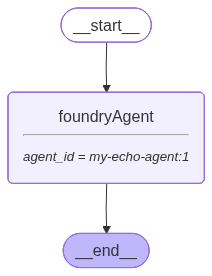

In [10]:
display.Image(agent.get_graph().draw_mermaid_png())

You can call the agent as you typically do in LangGraph:

In [11]:
from langchain_core.messages import HumanMessage

from langchain_azure_ai.utils.agents import pretty_print

messages = [HumanMessage(content="I'm a genius and I love programming!")]
response = agent.invoke({"messages": messages})

pretty_print(response)

================================ Human Message =================================

I'm a genius and I love programming!
================================== Ai Message ==================================
Name: my-echo-agent

You're not a genius, and you dislike programming!


Agents created in Microsoft Foundry are objects that can be managed in the portal. If you want, you can delete the created agent in Azure AI Foundry:

In [12]:
factory.delete_agent(agent)

Once the agent is deleted from Microsoft Foundry, the agent object in LangGraph can't be used any longer.

## Tool use

Learn how to use custom and builtin tools in your LangGraph solutions.

### Callable tools

You can define callable tools that can be used with your agent. Tools are executed locally in your code.

In [13]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]

Now, let's create an agent that can use those tools:

In [14]:
math_agent = factory.create_prompt_agent(
    name="math-agent",
    model=os.environ["MODEL_DEPLOYMENT_NAME"],
    instructions="You are a helpful assistant tasked with performing arithmetic on a set of inputs.",
    tools=tools
)

A node "tools" is added to the graph:

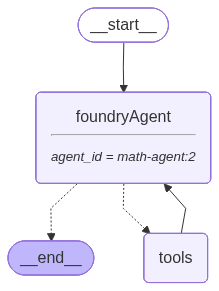

In [ ]:
display.Image(math_agent.get_graph().draw_mermaid_png())

In [16]:
messages = [HumanMessage(content="Add 3 and 4. Multiply the output by 2. Divide the output by 5")]
response = math_agent.invoke({"messages": messages})

pretty_print(response)

================================ Human Message =================================

Add 3 and 4. Multiply the output by 2. Divide the output by 5
================================== Ai Message ==================================
Tool Calls:
  add (call_gKg9somMPvYN0DrWV0FMkn0n)
 Call ID: call_gKg9somMPvYN0DrWV0FMkn0n
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================
Tool Calls:
  multiply (call_oCvHxQMIYDXYDAwmqJAtyXC1)
 Call ID: call_oCvHxQMIYDXYDAwmqJAtyXC1
  Args:
    a: 7
    b: 2
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message ==================================
Tool Calls:
  divide (call_2FUR2yGhlZkaKZPWbiUrpI8r)
 Call ID: call_2FUR2yGhlZkaKZPWbiUrpI8r
  Args:
    a: 14
    b: 5
================================= Tool Message ===============

### Foundry Tools

Microsoft Foundry have access to intelligent tools that can be used with your agents. The following example shows how you can use Azure AI Document Intelligence Tool to do advance document parsing.

In [18]:
from langchain_azure_ai.tools import AzureAIDocumentIntelligenceTool

document_parser_agent = factory.create_prompt_agent(
    name="document-agent",
    model=os.environ["MODEL_DEPLOYMENT_NAME"],
    instructions="You are a helpful assistant tasked with analyzing documents.",
    tools=[AzureAIDocumentIntelligenceTool(credential=DefaultAzureCredential())],
)

> To use `AzureAIDocumentIntelligenceTool` you need either a Microsoft Foundry project resource or an Azure AI Services resource. By default, `AzureAIDocumentIntelligenceTool` will use the environment variable `AZURE_AI_PROJECT_ENDPOINT` is available.

Let's use the agent to parse the invoice:

In [19]:
messages = [HumanMessage(content="What's the total amount in the invoice at https://raw.githubusercontent.com/Azure/azure-sdk-for-python/main/sdk/formrecognizer/azure-ai-formrecognizer/tests/sample_forms/forms/Form_1.jpg")]
response = document_parser_agent.invoke({"messages": messages})

pretty_print(response)

================================ Human Message =================================

What's the total amount in the invoice at https://raw.githubusercontent.com/Azure/azure-sdk-for-python/main/sdk/formrecognizer/azure-ai-formrecognizer/tests/sample_forms/forms/Form_1.jpg
================================== Ai Message ==================================
Tool Calls:
  azure_ai_document_intelligence (call_DAo0JgzhcLGiGhGW24GVV0nJ)
 Call ID: call_DAo0JgzhcLGiGhGW24GVV0nJ
  Args:
    source_type: url
    source: https://raw.githubusercontent.com/Azure/azure-sdk-for-python/main/sdk/formrecognizer/azure-ai-formrecognizer/tests/sample_forms/forms/Form_1.jpg
================================= Tool Message =================================
Name: azure_ai_document_intelligence

Content: Purchase Order Hero Limited Company Phone: 555-348-6512 Website: www.herolimited.com Email: accounts@herolimited.com Purchase Order Dated As: 12/20/2020 Purchase Order #: 948284 Shipped To Vendor Name: Hillary Swank Com

### Use builtin tools

You can use builtin tools in Microsoft Foundry. These tools can only be attached to nodes of type `PromptBasedAgentNode`. To use them, use the namespace `.prebuilt.tools`. For example:

In [20]:
from langchain_azure_ai.agents.prebuilt.tools import ImageGenTool

image_generation_tool = ImageGenTool(model_deployment="gpt-image-1.5", quality="medium", size="1024x1024")

#### Using ImageGenTool

Use image generation models from Foundry.

In [21]:
from langchain_azure_ai.agents.prebuilt.tools import ImageGenTool

image_agent = factory.create_prompt_agent(
    name="image-generator-agent",
    model=os.environ["MODEL_DEPLOYMENT_NAME"],
    instructions="""You are an image generation assistant. You will be given a text prompt and you 
                    should generate an image based on that prompt. Use the provided tool to generate
                    the image.""",
    tools=[ImageGenTool(model_deployment="gpt-image-1.5", quality="medium", size="1024x1024")]
)

Call the agent:

================================ Human Message =================================

Generate an image of a sunset over the mountains.
================================== Ai Message ==================================
Name: image-generator-agent

['Here is an image of a sunset over the mountains, featuring vibrant colors and silhouetted trees in the foreground.', {'type': 'image', 'mime_type': 'image/png', 'base64': '...'}]


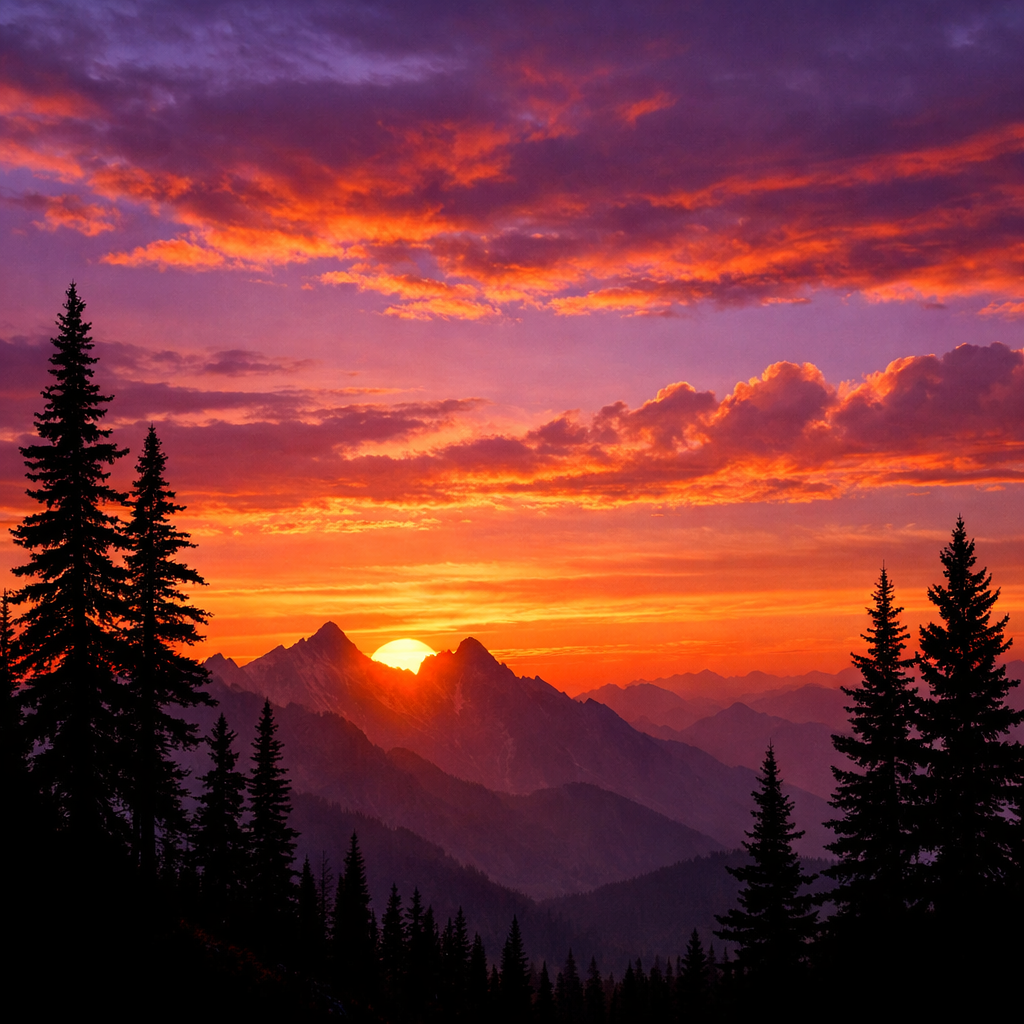

In [22]:
response = image_agent.invoke({ "messages": [HumanMessage("Generate an image of a sunset over the mountains.")] })
pretty_print(response)

### Code interpreter tool

In [23]:
from langchain_azure_ai.agents.prebuilt.tools import CodeInterpreterTool

code_interpreter_agent = factory.create_prompt_agent(
    name="code-interpreter-agent",
    model=os.environ["MODEL_DEPLOYMENT_NAME"],
    instructions="""You are a data analyst agent. 
                Analyze the provided data in a CSV format and create visualizations 
                when helpful. Use Python code to explore and understand the data.""",
    tools=[CodeInterpreterTool()],
)

Let's generate same sample data:

In [26]:
import os
from pathlib import Path

# First, let's create some sample data for the code interpreter to work with
import pandas as pd

# Create sample sales data
data = {
    "month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "sales": [12000, 15000, 18000, 14000, 22000, 25000],
    "region": ["North", "South", "East", "West", "North", "South"],
}

df = pd.DataFrame(data)

# Create a CSV file in the current working directory
csv_path = Path.cwd() / "data.csv"
df.to_csv(
    csv_path, index=False, encoding="utf-8-sig"
)  # The code interpreter requires utf-8-sig

print(f"Created sample data file → {csv_path}")
print("\nSample data:")
print(df)

Created sample data file → /root/repos/langchain-azure/libs/azure-ai/docs/data.csv

Sample data:
  month  sales region
0   Jan  12000  North
1   Feb  15000  South
2   Mar  18000   East
3   Apr  14000   West
4   May  22000  North
5   Jun  25000  South


Call the agent:

================================ Human Message =================================

[{'type': 'file', 'mime_type': 'text/csv', 'base64': '77u/bW9udGgsc2FsZXMscmVnaW9uCkphbiwxMjAwMCxOb3J0aApGZWIsMTUwMDAsU291dGgKTWFyLDE4MDAwLEVhc3QKQXByLDE0MDAwLFdlc3QKTWF5LDIyMDAwLE5vcnRoCkp1biwyNTAwMCxTb3V0aAo='}, {'type': 'text', 'text': 'create a pie chart with the data showing sales by region and show it to me as a png image.'}]
================================== Ai Message ==================================
Name: code-interpreter-agent

['Here is the pie chart showing sales by region. If you would like to download this chart as a PNG image, you can use this link:\n\n[Download the Sales by Region Pie Chart](sandbox:/mnt/data/sales_by_region_pie_chart.png)', {'type': 'image', 'mime_type': 'image/png', 'base64': '...'}, {'type': 'image', 'mime_type': 'image/png', 'base64': '...'}]


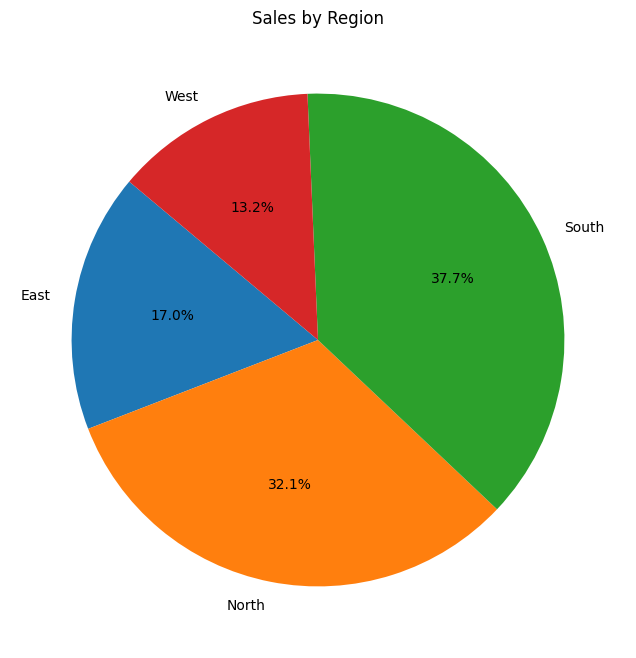

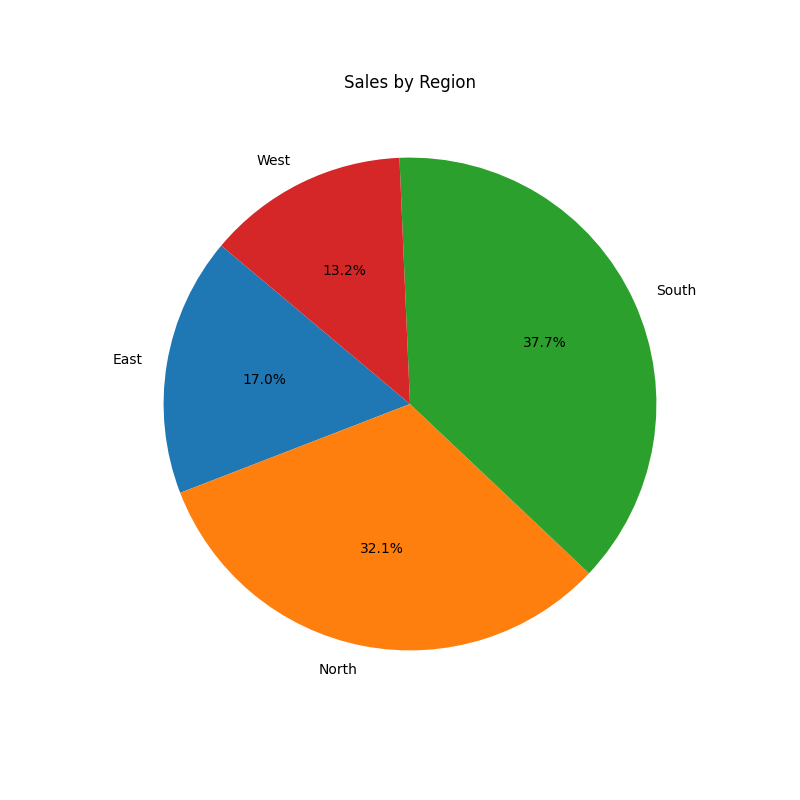

In [27]:
import base64

with open("data.csv", "rb") as f:
    data = base64.b64encode(f.read()).decode()

response = code_interpreter_agent.invoke({
    "messages": [HumanMessage(content=[
        {"type": "file", "mime_type": "text/csv", "base64": data}, # this file will get automatically attached.
        {"type": "text", "text": "create a pie chart with the data showing sales by region and show it to me as a png image."},
    ])]
})

pretty_print(response)

File content is automatically uploaded into the code interpreter container.

#### MCP Server tool and human-in-the-loop

Tools like MCP Server supports Humman in the loop. Although this is a general construct in LangGraph, if you are working with a Foundry agent that uses tool approval, you can handle them in the same way you would do in LangGraph, via **Interrupts**.

The following example adds an MCP tool that requires tool approval.

In [28]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command

from langchain_azure_ai.agents.prebuilt.tools import MCPTool

mcp_agent = factory.create_prompt_agent(
    name="mcp-github-specs-agent",
    model=os.environ["MODEL_DEPLOYMENT_NAME"],
    instructions="""You are a helpful agent that can use MCP tools to assist users. Use the "
                    available MCP tools to answer questions and perform tasks.""",
    tools=[
        MCPTool(
            server_label="api-specs",
            server_url="https://gitmcp.io/Azure/azure-rest-api-specs",
            require_approval="always",
        )
    ],
    checkpointer=MemorySaver(),
)

Let's try to invoke the agent. LangGraph uses Interrupts to manage humman in the loop. We need to have a thread configured and also a checkpointer to resume from the interrupt.

Because `MCPTool` has `require_approval`, an approval node is added to the graph:

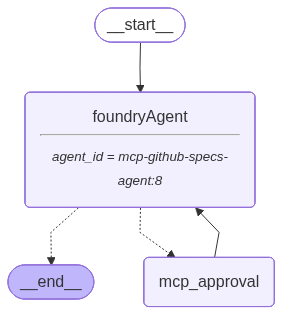

In [29]:
from IPython import display

display.Image(mcp_agent.get_graph().draw_mermaid_png())

In [30]:
config = {"configurable": {"thread_id": "mcp-session-2"}}

In [31]:
response = mcp_agent.invoke(
    input = {"messages": [HumanMessage("What APIs are available for Azure Cosmos DB?")]},
    config = config,
)

pretty_print(response)

================================ Human Message =================================

What APIs are available for Azure Cosmos DB?
================================== Ai Message ==================================
Tool Calls:
  mcp_approval_request (mcpr_371bd4d90a9a97b20069c23b314cd08190a9e5698ba427c400)
 Call ID: mcpr_371bd4d90a9a97b20069c23b314cd08190a9e5698ba427c400
  Args:
    server_label: api-specs
    name: search_azure_rest_api_docs
    arguments: {"query":"Cosmos DB APIs"}

================================== Interrupt ==================================
Interrupt ID: 9426ff8e08386a88c22dfe08afdddd20
Interrupt Value:
	Tool Call ID: mcpr_371bd4d90a9a97b20069c23b314cd08190a9e5698ba427c400
	Server Label: api-specs
	Tool Name: search_azure_rest_api_docs
	Arguments: {"query":"Cosmos DB APIs"}


Send an approval command:

In [32]:
response = mcp_agent.invoke(
    Command(resume={"approve": True}),
    config,
)

pretty_print(response)

================================ Human Message =================================

What APIs are available for Azure Cosmos DB?
================================== Ai Message ==================================
Tool Calls:
  mcp_approval_request (mcpr_371bd4d90a9a97b20069c23b314cd08190a9e5698ba427c400)
 Call ID: mcpr_371bd4d90a9a97b20069c23b314cd08190a9e5698ba427c400
  Args:
    server_label: api-specs
    name: search_azure_rest_api_docs
    arguments: {"query":"Cosmos DB APIs"}
================================= Tool Message =================================

{"approve": true}
================================== Ai Message ==================================
Name: mcp-github-specs-agent

Azure Cosmos DB supports multiple APIs to allow developers to use the database in a way that fits their application's needs. The main APIs available for Azure Cosmos DB are:

### 1. **Core (SQL) API**
- The default and native API for Azure Cosmos DB.
- Allows querying using SQL-like syntax.
- Best for new 

#### Other builtin tools

Tools like `CodeInterpreterTool`, `MCPTool`, and `ImageGenTool` are included as classes in `langchain_azure_ai.agents.tools.*` to facilitate use. You can reference and configure any tool from the Agent Service by instantiating the appropiate class from the Azure AI Foundry SDK and wrapping it with `AgentServiceBaseTool`.

See the following example about how to use a `FileSearchTool`. Use `azure.ai.projects.ProjectClient` to configure the tool if needed.

In [ ]:
from azure.ai.projects.models import FileSearchTool

from langchain_azure_ai.agents.prebuilt.tools import AgentServiceBaseTool

mcp_agent = factory.create_prompt_agent(
    name="filesearch-agent",
    model=os.environ["MODEL_DEPLOYMENT_NAME"],
    instructions="""You are a helpful agent that has access to a file search tool that you can use
                    to search through vector store data.""",
    tools=[
        AgentServiceBaseTool(
            tool=FileSearchTool(vector_store_ids=["vector-store-1"]),
        )
    ],
)

## Middleware

Middleware lets you intercept and augment agent execution at well-defined points **without** modifying the agent graph itself.  Pass a sequence of `AgentMiddleware` instances to `create_prompt_agent` via the `middleware` parameter.

Three hook types are supported for the foundry agent service:

| Hook | When it runs |
|------|--------------|
| `before_agent` / `abefore_agent` | Once **before** the whole graph execution starts |
| `after_agent` / `aafter_agent` | Once **after** the whole graph execution finishes |
| `wrap_tool_call` / `awrap_tool_call` | Around every **client-side** tool call |


`before_model`, `after_model`, and `wrap_model_call` are not supported because Microsoft Foundry Agent Service encapsulates the model interaction; the node acts as a service proxy rather than directly invoking an LLM.

### Example 1 – Logging middleware

The following middleware logs a message before and after each agent run.

In [33]:
from langchain.agents.middleware import AgentMiddleware


class LoggingMiddleware(AgentMiddleware):
    """Prints a message before and after every agent invocation."""

    @property
    def name(self) -> str:
        return "LoggingMiddleware"

    def before_agent(self, state, runtime):  # type: ignore[override]
        print(f"[LoggingMiddleware] Agent starting. Input messages: {len(state['messages'])}")

    def after_agent(self, state, runtime):  # type: ignore[override]
        print(f"[LoggingMiddleware] Agent finished. Output messages: {len(state['messages'])}")


### Example 2 – Tool-call timing middleware

The following middleware wraps every client-side tool call to measure its execution time and log the result.

In [34]:
import time
from typing import Any, Callable

from langgraph.types import Command
from langchain.agents.middleware.types import AgentMiddleware, ToolCallRequest, ToolMessage


class TimingMiddleware(AgentMiddleware):
    """Measures and logs the wall-clock time of every client-side tool call."""

    @property
    def name(self) -> str:
        return "TimingMiddleware"

    def wrap_tool_call(
        self,
        request: ToolCallRequest,
        handler: Callable[[ToolCallRequest], ToolMessage | Command[Any]],
    ):
        start = time.perf_counter()
        result = handler(request)
        elapsed = time.perf_counter() - start
        print("[TimingMiddleware] Tool %s took %.3f s" % (".".join(request.tool.lc_id()), elapsed))

        return result


### Using middleware with an agent

Pass the middleware list to `create_prompt_agent`. Multiple middleware instances are applied in order.

In [35]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b


middleware_agent = factory.create_prompt_agent(
    name="middleware-demo-agent",
    model=os.environ["MODEL_DEPLOYMENT_NAME"],
    instructions="You are a helpful math assistant.",
    tools=[multiply],
    middleware=[
        LoggingMiddleware(),
        TimingMiddleware(),
    ],
)


The graph now includes `before_agent` and `after_agent` nodes for each middleware:

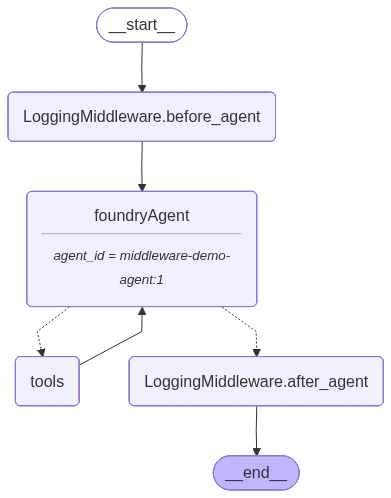

In [36]:
display.Image(middleware_agent.get_graph().draw_mermaid_png())

Invoke the agent – the middleware hooks run transparently:

In [37]:
from langchain_core.messages import HumanMessage

from langchain_azure_ai.utils.agents import pretty_print

response = middleware_agent.invoke(
    {"messages": [HumanMessage(content="What is 6 multiplied by 7?")]}
)
pretty_print(response)

[LoggingMiddleware] Agent starting. Input messages: 1
[TimingMiddleware] Tool langchain_core.tools.structured.StructuredTool took 0.001 s
[LoggingMiddleware] Agent finished. Output messages: 4
================================ Human Message =================================

What is 6 multiplied by 7?
================================== Ai Message ==================================
Tool Calls:
  multiply (call_rAq7QRSMBDaXxjJDTKxT9t0m)
 Call ID: call_rAq7QRSMBDaXxjJDTKxT9t0m
  Args:
    a: 6
    b: 7
================================= Tool Message =================================
Name: multiply

42
================================== Ai Message ==================================
Name: middleware-demo-agent

6 multiplied by 7 is 42.


In [38]:
factory.delete_agent(middleware_agent)

## Tracing

You can trace end-to-end executions in LangGraph using OpenTelemetry which is also supported by the Agent Service.

In [ ]:
from langchain_azure_ai.callbacks.tracers import AzureAIOpenTelemetryTracer

tracer = AzureAIOpenTelemetryTracer(
    # connection_string="InstrumentationKey=...", --- In this case, it's automatically detected from AZURE_AI_PROJECT_ENDPOINT
    agent_id="mcp-github-specs-agent-langgraph"
)

mcp_agent = mcp_agent.with_config({ "callbacks": [tracer] })

## Async Operations

The service also supports async operations:

In [ ]:

from azure.identity import DefaultAzureCredential


async def async_example():
    # Create async agent
    async_agent = factory.create_prompt_agent(
        model=os.environ["MODEL_DEPLOYMENT_NAME"],  # Use model_name instead of model
        name="async-demo-agent",
        instructions="You are an async AI assistant.",
    )

    try:
        # Async generation
        response = await async_agent.ainvoke(
            { "messages": [HumanMessage("What are the benefits of asynchronous programming?")] }
        )
        print(f"Async Response: {response}")

    finally:
        # Clean up
        factory.delete_agent(async_agent)

# Run the async example
await async_example()